In [1]:
# Important Variables

In [2]:
attackType = "Trojan"
energyPercentage = "40"
attackDuration = "10ms"

In [3]:
# Libraries

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os.path
import joblib

In [5]:
# Get Training Data

In [6]:
base_name = f"{attackType}_{energyPercentage}_{attackDuration}"

X_train = pd.read_csv(f'../Packet Flows Preprocessing/Training Data/X_train/{base_name}_X_train.csv')
X_test = pd.read_csv(f'../Packet Flows Preprocessing/Training Data/X_test/{base_name}_X_test.csv')
y_train = pd.read_csv(f'../Packet Flows Preprocessing/Training Data/y_train/{base_name}_y_train.csv')
y_test = pd.read_csv(f'../Packet Flows Preprocessing/Training Data/y_test/{base_name}_y_test.csv')

In [7]:
## Test Shapes

In [8]:
X_train.shape

(8851, 5)

In [9]:
X_test.shape

(2213, 5)

In [10]:
y_train.shape

(8851, 1)

In [11]:
y_test.shape

(2213, 1)

In [12]:
# Results Array

In [13]:
results = pd.DataFrame(columns=['Algorithm', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'KFold', 'ROC Curve'])

In [14]:
# Random Forest

/home/berei/.local/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/berei/.local/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/berei/.local/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/berei/.local/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y 

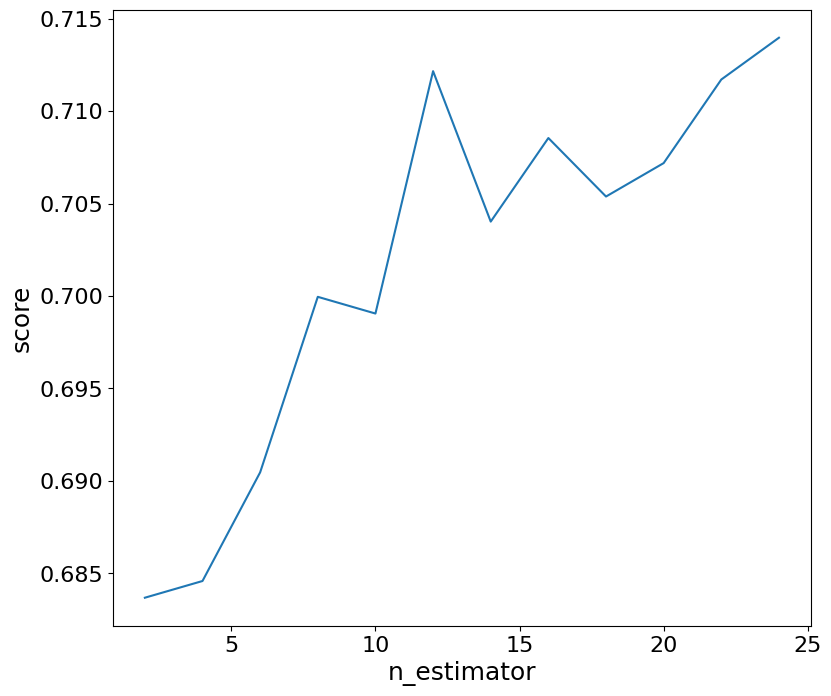

In [15]:

from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

estimator_range = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24]

models = []
scores = []

for n_estimators in estimator_range:
    clf = RandomForestClassifier(n_estimators= n_estimators, random_state = 22)
    clf.fit(X_train, y_train)
    models.append(clf)
    scores.append(accuracy_score(y_true=y_test, y_pred = clf.predict(X_test)))
    
plt.figure(figsize=(9,8))  
plt.plot(estimator_range, scores)
plt.xlabel("n_estimator", fontsize = 18)
plt.ylabel("score", fontsize = 18)
plt.tick_params(labelsize = 16)

plt.show()

In [16]:
## Get Optimimal Number of Estimators

In [17]:
estimators = 4

In [18]:
## Train and Test

In [19]:
from sklearn.ensemble import RandomForestClassifier

classifier= RandomForestClassifier(n_estimators= estimators, criterion="entropy")  
classifier.fit(X_train, y_train)  

/home/berei/.local/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",4
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

In [20]:
y_pred= classifier.predict(X_test)

In [21]:
## Calculate Metrics

In [22]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)

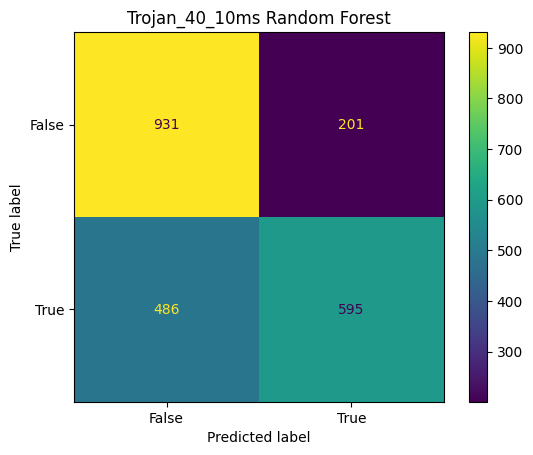

In [23]:
if not os.path.exists('Confusion Matrix/' + attackType + '/' + energyPercentage + '/' + attackDuration):
    os.makedirs('Confusion Matrix/' + attackType + '/' + energyPercentage + '/' + attackDuration)

cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=[False, True], )

cm_display.plot()
cm_display.ax_.set_title(f'{base_name}' + ' Random Forest')
plt.savefig('Confusion Matrix/' + attackType + '/' + energyPercentage + '/' + attackDuration + f'/{base_name}_conf_mat_Random_Forest',dpi=300)

In [24]:
from sklearn.metrics import accuracy_score
AS = accuracy_score(y_true=y_test, y_pred = classifier.predict(X_test))
AS

0.6895616809760506

In [25]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)
print(f'Model 1 AUC score: {precision}')

Model 1 AUC score: 0.7474874371859297


In [26]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)
print(f'Model 1 AUC score: {recall}')

Model 1 AUC score: 0.5504162812210915


In [27]:
from sklearn.metrics import f1_score

f1score = f1_score(y_test, y_pred)
print(f'Model 1 AUC score: {f1score}')

Model 1 AUC score: 0.633990410229089


In [28]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

k_fold = StratifiedKFold(n_splits = 5)

kfoldscores = cross_val_score(classifier, X_test, y_test, cv=k_fold)

print("Cross Validation scores: ", kfoldscores)
print("Average CV scores: ", kfoldscores.mean())
print("Number of CV Scores in Average: ", len(kfoldscores))

Cross Validation scores:  [0.64334086 0.65688488 0.68171558 0.64932127 0.66968326]
Average CV scores:  0.6601891668283912
Number of CV Scores in Average:  5


/home/berei/.local/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/berei/.local/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/berei/.local/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/berei/.local/lib/python3.14/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y 

Model 1 AUC score: 0.6864272218826306


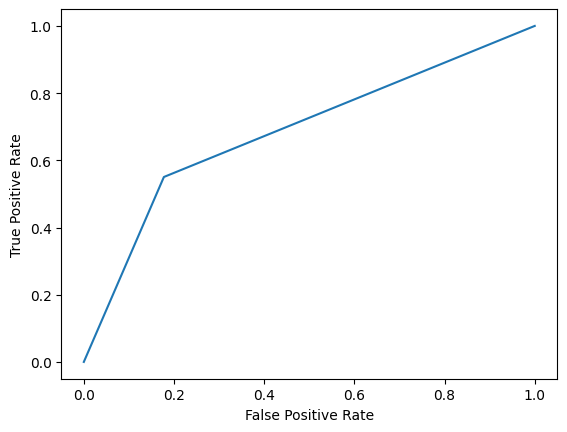

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score

def plot_roc_curve(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    plt.plot(fpr, tpr)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')

plot_roc_curve(y_test, y_pred)
print(f'Model 1 AUC score: {roc_auc_score(y_test, y_pred)}')
aucScore = roc_auc_score(y_test, y_pred)

In [30]:
tempResults = pd.DataFrame([["Random Forest (4 n_estimators)", AS, precision, recall, f1score, kfoldscores.mean(), aucScore]], columns=['Algorithm', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'KFold', 'ROC Curve'])
results = pd.concat([results, tempResults])
results

,Algorithm,Accuracy,Precision,Recall,F1-Score,KFold,ROC Curve
0,Random Forest (4 n_estimators),0.689562,0.747487,0.550416,0.63399,0.660189,0.686427


In [31]:
## Save Models

In [32]:
if not os.path.exists(f'Models/{attackType}/{energyPercentage}/{attackDuration}'):
    os.makedirs(f'Models/{attackType}/{energyPercentage}/{attackDuration}')

In [33]:
filename = f'Models/{attackType}/{energyPercentage}/{attackDuration}/Random_Forest.sav'
joblib.dump(classifier, filename)

['Models/Trojan/40/10ms/Random_Forest.sav']

In [34]:
from sklearn.naive_bayes import GaussianNB

classifier = GaussianNB()
classifier.fit(X_train, y_train)

/home/berei/.local/lib/python3.14/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [35]:
y_pred = classifier.predict(X_test)

In [36]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)

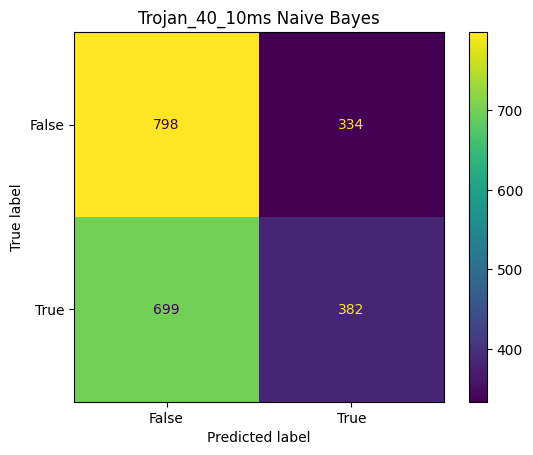

In [37]:
if not os.path.exists('Confusion Matrix/' + attackType + '/' + energyPercentage + '/' + attackDuration):
    os.makedirs('Confusion Matrix/' + attackType + '/' + energyPercentage + '/' + attackDuration)

cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=[False, True], )

cm_display.plot()
cm_display.ax_.set_title(f'{base_name}' + ' Naive Bayes')
plt.savefig('Confusion Matrix/' + attackType + '/' + energyPercentage + '/' + attackDuration + f'/{base_name}_conf_mat_Naive_Bayes',dpi=300)

In [38]:
AS = accuracy_score(y_true=y_test, y_pred = classifier.predict(X_test))
AS

0.5332128332580208

In [39]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)
print(f'Model 1 AUC score: {precision}')

Model 1 AUC score: 0.5335195530726257


In [40]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)
print(f'Model 1 AUC score: {recall}')

Model 1 AUC score: 0.35337650323774283


In [41]:
from sklearn.metrics import f1_score

f1score = f1_score(y_test, y_pred)
print(f'Model 1 AUC score: {f1score}')

Model 1 AUC score: 0.4251530328324986


In [42]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

k_fold = StratifiedKFold(n_splits = 5)

kfoldscores = cross_val_score(classifier, X_test, y_test, cv=k_fold)

print("Cross Validation scores: ", kfoldscores)
print("Average CV scores: ", kfoldscores.mean())
print("Number of CV Scores in Average: ", len(kfoldscores))

Cross Validation scores:  [0.50564334 0.54401806 0.51241535 0.49321267 0.53393665]
Average CV scores:  0.5178452141405269
Number of CV Scores in Average:  5


/home/berei/.local/lib/python3.14/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/berei/.local/lib/python3.14/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/berei/.local/lib/python3.14/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/berei/.local/lib/python3.14/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape

Model 1 AUC score: 0.529161749852087


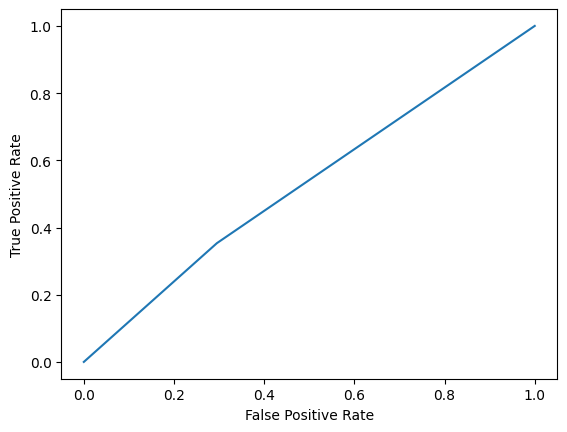

In [43]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score

def plot_roc_curve(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    plt.plot(fpr, tpr)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')

plot_roc_curve(y_test, y_pred)
print(f'Model 1 AUC score: {roc_auc_score(y_test, y_pred)}')
aucScore = roc_auc_score(y_test, y_pred)

In [44]:
tempResults = pd.DataFrame([["Naive Bayes (Gaussian)", AS, precision, recall, f1score, kfoldscores.mean(), aucScore]], columns=['Algorithm', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'KFold', 'ROC Curve'])
results = pd.concat([results, tempResults])
results

,Algorithm,Accuracy,Precision,Recall,F1-Score,KFold,ROC Curve
0,Random Forest (4 n_estimators),0.689562,0.747487,0.550416,0.63399,0.660189,0.686427
0,Naive Bayes (Gaussian),0.533213,0.53352,0.353377,0.425153,0.517845,0.529162


In [45]:
filename = f'Models/{attackType}/{energyPercentage}/{attackDuration}/Naive_Bayes.sav'
joblib.dump(classifier, filename)

['Models/Trojan/40/10ms/Naive_Bayes.sav']

In [46]:
# K-Nearest-Neighbors

In [47]:
from sklearn.neighbors import KNeighborsClassifier

classifier = KNeighborsClassifier(n_neighbors = 1)

classifier.fit(X_train, y_train)

/home/berei/.local/lib/python3.14/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [48]:
y_pred = classifier.predict(X_test)

In [49]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)

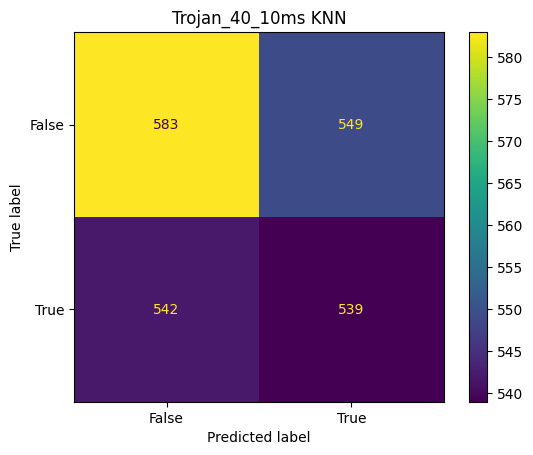

In [50]:
if not os.path.exists('Confusion Matrix/' + attackType + '/' + energyPercentage + '/' + attackDuration):
    os.makedirs('Confusion Matrix/' + attackType + '/' + energyPercentage + '/' + attackDuration)

cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=[False, True], )

cm_display.plot()
cm_display.ax_.set_title(f'{base_name}' + ' KNN')
plt.savefig('Confusion Matrix/' + attackType + '/' + energyPercentage + '/' + attackDuration + f'/{base_name}_conf_mat_KNN',dpi=300)

In [51]:
AS = accuracy_score(y_true=y_test, y_pred = classifier.predict(X_test))
AS

0.5070040668775418

In [52]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)
print(f'Model 1 AUC score: {precision}')

Model 1 AUC score: 0.4954044117647059


In [53]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)
print(f'Model 1 AUC score: {recall}')

Model 1 AUC score: 0.49861239592969475


In [54]:
from sklearn.metrics import f1_score

f1score = f1_score(y_test, y_pred)
print(f'Model 1 AUC score: {f1score}')

Model 1 AUC score: 0.49700322729368374


In [55]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

k_fold = StratifiedKFold(n_splits = 5)

kfoldscores = cross_val_score(classifier, X_test, y_test, cv=k_fold)

print("Cross Validation scores: ", kfoldscores)
print("Average CV scores: ", kfoldscores.mean())
print("Number of CV Scores in Average: ", len(kfoldscores))

Cross Validation scores:  [0.51918736 0.51241535 0.54176072 0.47511312 0.49547511]
Average CV scores:  0.5087903332890719
Number of CV Scores in Average:  5


/home/berei/.local/lib/python3.14/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/home/berei/.local/lib/python3.14/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/home/berei/.local/lib/python3.14/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/home/berei/.local/lib/python3.14/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the 

Model 1 AUC score: 0.5068150318871089


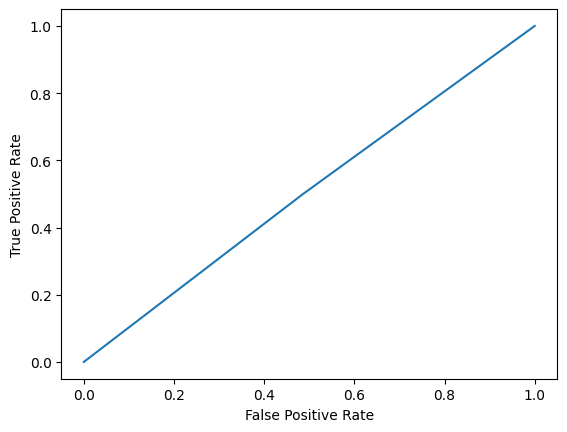

In [56]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score

def plot_roc_curve(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    plt.plot(fpr, tpr)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')

plot_roc_curve(y_test, y_pred)
print(f'Model 1 AUC score: {roc_auc_score(y_test, y_pred)}')
aucScore = roc_auc_score(y_test, y_pred)

In [57]:
tempResults = pd.DataFrame([["KNN", AS, precision, recall, f1score, kfoldscores.mean(), aucScore]], columns=['Algorithm', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'KFold', 'ROC Curve'])
results = pd.concat([results, tempResults])
results

,Algorithm,Accuracy,Precision,Recall,F1-Score,KFold,ROC Curve
0,Random Forest (4 n_estimators),0.689562,0.747487,0.550416,0.63399,0.660189,0.686427
0,Naive Bayes (Gaussian),0.533213,0.53352,0.353377,0.425153,0.517845,0.529162
0,KNN,0.507004,0.495404,0.498612,0.497003,0.50879,0.506815


In [58]:
filename = f'Models/{attackType}/{energyPercentage}/{attackDuration}/KNN.sav'
joblib.dump(classifier, filename)

['Models/Trojan/40/10ms/KNN.sav']

In [59]:
# Logistic Regression

In [60]:
from sklearn import linear_model

classifier = linear_model.LogisticRegression()
classifier.fit(X_train, y_train)

/home/berei/.local/lib/python3.14/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [61]:
y_pred = classifier.predict(X_test)

In [62]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)

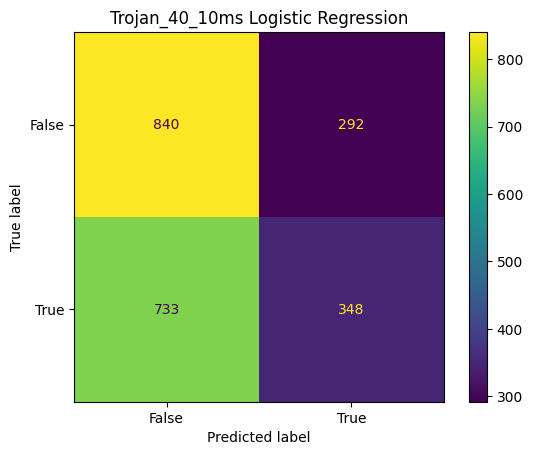

In [63]:
if not os.path.exists('Confusion Matrix/' + attackType + '/' + energyPercentage + '/' + attackDuration):
    os.makedirs('Confusion Matrix/' + attackType + '/' + energyPercentage + '/' + attackDuration)

cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=[False, True], )

cm_display.plot()
cm_display.ax_.set_title(f'{base_name}' + ' Logistic Regression')
plt.savefig('Confusion Matrix/' + attackType + '/' + energyPercentage + '/' + attackDuration + f'/{base_name}_conf_mat_Logistic_Regression',dpi=300)

In [64]:
AS = accuracy_score(y_true=y_test, y_pred = classifier.predict(X_test))
AS

0.5368278355173972

In [65]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)
print(f'Model 1 AUC score: {precision}')

Model 1 AUC score: 0.54375


In [66]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)
print(f'Model 1 AUC score: {recall}')

Model 1 AUC score: 0.32192414431082333


In [67]:
from sklearn.metrics import f1_score

f1score = f1_score(y_test, y_pred)
print(f'Model 1 AUC score: {f1score}')

Model 1 AUC score: 0.4044160371876816


In [68]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

k_fold = StratifiedKFold(n_splits = 5)

kfoldscores = cross_val_score(classifier, X_test, y_test, cv=k_fold)

print("Cross Validation scores: ", kfoldscores)
print("Average CV scores: ", kfoldscores.mean())
print("Number of CV Scores in Average: ", len(kfoldscores))

Cross Validation scores:  [0.51241535 0.55530474 0.5214447  0.5158371  0.52036199]
Average CV scores:  0.5250727761151344
Number of CV Scores in Average:  5


/home/berei/.local/lib/python3.14/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/berei/.local/lib/python3.14/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/berei/.local/lib/python3.14/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/berei/.local/lib/python3.14/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape

Model 1 AUC score: 0.5319868071377438


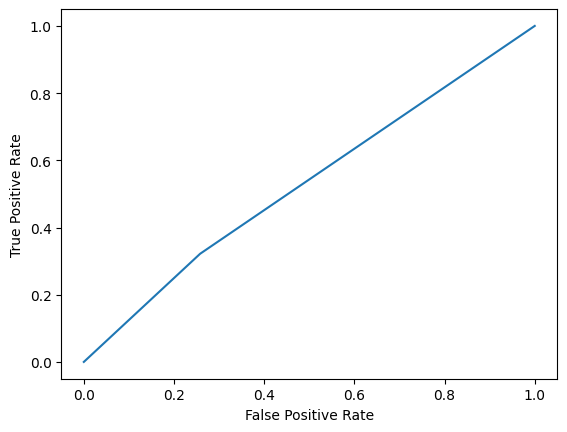

In [69]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score

def plot_roc_curve(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    plt.plot(fpr, tpr)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')

plot_roc_curve(y_test, y_pred)
print(f'Model 1 AUC score: {roc_auc_score(y_test, y_pred)}')
aucScore = roc_auc_score(y_test, y_pred)

In [70]:
tempResults = pd.DataFrame([["Logistic Regression", AS, precision, recall, f1score, kfoldscores.mean(), aucScore]], columns=['Algorithm', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'KFold', 'ROC Curve'])
results = pd.concat([results, tempResults])
results

,Algorithm,Accuracy,Precision,Recall,F1-Score,KFold,ROC Curve
0,Random Forest (4 n_estimators),0.689562,0.747487,0.550416,0.63399,0.660189,0.686427
0,Naive Bayes (Gaussian),0.533213,0.53352,0.353377,0.425153,0.517845,0.529162
0,KNN,0.507004,0.495404,0.498612,0.497003,0.50879,0.506815
0,Logistic Regression,0.536828,0.54375,0.321924,0.404416,0.525073,0.531987


In [71]:
filename = f'Models/{attackType}/{energyPercentage}/{attackDuration}/Logistic_Regression.sav'
joblib.dump(classifier, filename)

['Models/Trojan/40/10ms/Logistic_Regression.sav']

In [72]:
# Support Vector Machine

In [73]:
from sklearn import svm

classifier = svm.LinearSVC()

classifier.fit(X_train, y_train)

/home/berei/.local/lib/python3.14/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [74]:
y_pred = classifier.predict(X_test)

In [75]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)

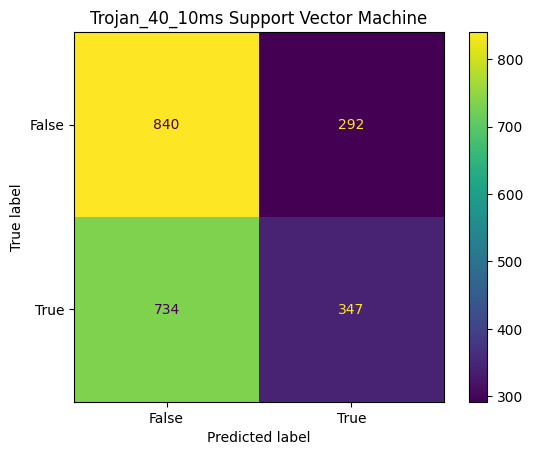

In [76]:
if not os.path.exists('Confusion Matrix/' + attackType + '/' + energyPercentage + '/' + attackDuration):
    os.makedirs('Confusion Matrix/' + attackType + '/' + energyPercentage + '/' + attackDuration)

cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=[False, True], )

cm_display.plot()
cm_display.ax_.set_title(f'{base_name}' + ' Support Vector Machine')
plt.savefig('Confusion Matrix/' + attackType + '/' + energyPercentage + '/' + attackDuration + f'/{base_name}_conf_mat_SVM',dpi=300)

In [77]:
AS = accuracy_score(y_true=y_test, y_pred = classifier.predict(X_test))
AS

0.5363759602349751

In [78]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)
print(f'Model 1 AUC score: {precision}')

Model 1 AUC score: 0.543035993740219


In [79]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)
print(f'Model 1 AUC score: {recall}')

Model 1 AUC score: 0.3209990749306198


In [80]:
from sklearn.metrics import f1_score

f1score = f1_score(y_test, y_pred)
print(f'Model 1 AUC score: {f1score}')

Model 1 AUC score: 0.40348837209302324


In [81]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

k_fold = StratifiedKFold(n_splits = 5)

kfoldscores = cross_val_score(classifier, X_test, y_test, cv=k_fold)

print("Cross Validation scores: ", kfoldscores)
print("Average CV scores: ", kfoldscores.mean())
print("Number of CV Scores in Average: ", len(kfoldscores))

Cross Validation scores:  [0.51241535 0.55530474 0.5214447  0.5158371  0.5158371 ]
Average CV scores:  0.5241677987395688
Number of CV Scores in Average:  5


/home/berei/.local/lib/python3.14/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/berei/.local/lib/python3.14/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/berei/.local/lib/python3.14/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/berei/.local/lib/python3.14/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape

Model 1 AUC score: 0.531524272447642


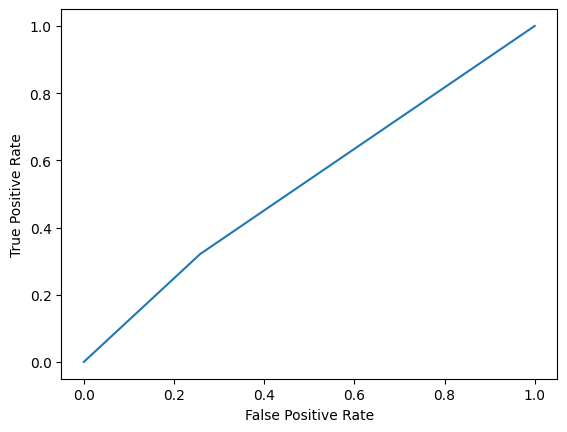

In [82]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score

def plot_roc_curve(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    plt.plot(fpr, tpr)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')

plot_roc_curve(y_test, y_pred)
print(f'Model 1 AUC score: {roc_auc_score(y_test, y_pred)}')
aucScore = roc_auc_score(y_test, y_pred)

In [83]:
tempResults = pd.DataFrame([["Support Vector Machine", AS, precision, recall, f1score, kfoldscores.mean(), aucScore]], columns=['Algorithm', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'KFold', 'ROC Curve'])
results = pd.concat([results, tempResults])
results

,Algorithm,Accuracy,Precision,Recall,F1-Score,KFold,ROC Curve
0,Random Forest (4 n_estimators),0.689562,0.747487,0.550416,0.63399,0.660189,0.686427
0,Naive Bayes (Gaussian),0.533213,0.53352,0.353377,0.425153,0.517845,0.529162
0,KNN,0.507004,0.495404,0.498612,0.497003,0.50879,0.506815
0,Logistic Regression,0.536828,0.54375,0.321924,0.404416,0.525073,0.531987
0,Support Vector Machine,0.536376,0.543036,0.320999,0.403488,0.524168,0.531524


In [84]:
filename = f'Models/{attackType}/{energyPercentage}/{attackDuration}/SVM.sav'
joblib.dump(classifier, filename)

['Models/Trojan/40/10ms/SVM.sav']

In [85]:
results = results.assign(row_number=range(len(results)))
results

,Algorithm,Accuracy,Precision,Recall,F1-Score,KFold,ROC Curve,row_number
0,Random Forest (4 n_estimators),0.689562,0.747487,0.550416,0.63399,0.660189,0.686427,0
0,Naive Bayes (Gaussian),0.533213,0.53352,0.353377,0.425153,0.517845,0.529162,1
0,KNN,0.507004,0.495404,0.498612,0.497003,0.50879,0.506815,2
0,Logistic Regression,0.536828,0.54375,0.321924,0.404416,0.525073,0.531987,3
0,Support Vector Machine,0.536376,0.543036,0.320999,0.403488,0.524168,0.531524,4


In [86]:
results.set_index('row_number', inplace=True, drop=True)

In [87]:
print(results)

                                 Algorithm  Accuracy Precision    Recall  \
row_number                                                                 
0           Random Forest (4 n_estimators)  0.689562  0.747487  0.550416   
1                   Naive Bayes (Gaussian)  0.533213   0.53352  0.353377   
2                                      KNN  0.507004  0.495404  0.498612   
3                      Logistic Regression  0.536828   0.54375  0.321924   
4                   Support Vector Machine  0.536376  0.543036  0.320999   

            F1-Score     KFold ROC Curve  
row_number                                
0            0.63399  0.660189  0.686427  
1           0.425153  0.517845  0.529162  
2           0.497003   0.50879  0.506815  
3           0.404416  0.525073  0.531987  
4           0.403488  0.524168  0.531524  


In [88]:
results.to_csv(f'Models/{attackType}/{energyPercentage}/{attackDuration}.csv')